In [2]:
import pandas as pd

# Read the CSV file into a pandas 'DataFrame' (like a virtual spreadsheet)
df = pd.read_csv('../dataset/spam.csv')

# Display the first 5 rows of the dataset
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
df['Category'].value_counts()

Category
ham     4825
spam     747
Name: count, dtype: int64

In [4]:
# 1. Check for missing values
print("Missing values before cleaning:\n", df.isnull().sum())

# 2. Drop any rows that are missing data
df = df.dropna()

# 3. Check for exact duplicate emails
print("\nDuplicates found:", df.duplicated().sum())

# 4. Drop the duplicates to keep the data clean
df = df.drop_duplicates(keep='first')

# 5. Convert our text labels ('ham'/'spam') into numbers (0/1)
# This is like converting a boolean to an integer for a database schema
df['Category'] = df['Category'].map({'ham': 0, 'spam': 1})

# Let's see the new, clean dataset!
df.head()

Missing values before cleaning:
 Category    0
Message     0
dtype: int64

Duplicates found: 415


,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
import spacy

# Load the English language model we downloaded in Phase 2
nlp = spacy.load("en_core_web_sm")

def clean_email_text(text):
    # 1. Convert text to lowercase and pass it to spaCy
    # spaCy automatically Tokenizes the sentence for us!
    doc = nlp(text.lower()) 
    
    cleaned_tokens = []
    
    # Loop through every single word (token) in the email
    for token in doc:
        # 2. Check if it's a standard alphabetical word (removes punctuation/numbers)
        # 3. Check if it is NOT a stop word
        if token.is_alpha and not token.is_stop:
            
            # 4. Grab the "lemma" (the root dictionary form of the word)
            cleaned_tokens.append(token.lemma_)
            
    # Join the array of cleaned words back into a single string
    return " ".join(cleaned_tokens)

# Let's test our function on a fake spam email!
test_email = "WINNER!! You have been selected to claim a FREE prize. Click here now!"
print("Original:", test_email)
print("Cleaned:", clean_email_text(test_email))

Original: WINNER!! You have been selected to claim a FREE prize. Click here now!
Cleaned: winner select claim free prize click


In [6]:
# Apply the cleaning function to the entire 'Message' column
# WARNING: This might take 30 to 60 seconds to run because NLP processing is heavy!
print("Cleaning emails... please wait...")

df['Cleaned_Message'] = df['Message'].apply(clean_email_text)

print("Done! Here is our final cleaned dataset:")
df[['Category', 'Message', 'Cleaned_Message']].head()

Cleaning emails... please wait...
Done! Here is our final cleaned dataset:


,Category,Message,Cleaned_Message
0,0,"Go until jurong point, crazy.. Available only ...",jurong point crazy available bugis n great wor...
1,0,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts tex...
3,0,U dun say so early hor... U c already then say...,u dun early hor u c
4,0,"Nah I don't think he goes to usf, he lives aro...",nah think go usf live


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Initialize the TF-IDF calculator
# We set a max_features limit to only keep the top 5000 most meaningful words, 
# which saves memory and prevents the model from learning completely useless typos.
vectorizer = TfidfVectorizer(max_features=5000)

# 2. Fit the vectorizer to our cleaned text and transform it into a number matrix (X)
X = vectorizer.fit_transform(df['Cleaned_Message'])

# 3. Isolate our labels (y) - this is just the column of 0s and 1s
y = df['Category']

# Print out the mathematical dimensions of our new data
print("Shape of our Feature Matrix (X):", X.shape)
print("Shape of our Labels Array (y):", y.shape)

Shape of our Feature Matrix (X): (5157, 5000)
Shape of our Labels Array (y): (5157,)


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# 1. Split the data (80% for training, 20% for testing)
# random_state=42 ensures that the random shuffle is the exact same every time we run the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Data Size:", X_train.shape[0], "emails")
print("Testing Data Size:", X_test.shape[0], "emails")

# 2. Initialize the Naive Bayes model
nb_model = MultinomialNB()

# 3. Train the model using our study material!
nb_model.fit(X_train, y_train)
print("\nModel training complete!")

# 4. Make predictions on the hidden 20% test data
nb_predictions = nb_model.predict(X_test)

# 5. Check our initial accuracy
initial_accuracy = accuracy_score(y_test, nb_predictions)
print(f"Naive Bayes Accuracy: {initial_accuracy * 100:.2f}%")

Training Data Size: 4125 emails
Testing Data Size: 1032 emails

Model training complete!
Naive Bayes Accuracy: 96.51%


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the competitor models
# We add parameters like max_iter to ensure the math has enough time to finish calculating
log_model = LogisticRegression(max_iter=1000)
svm_model = SVC(kernel='linear') # 'linear' creates a straight multidimensional line between data
rf_model = RandomForestClassifier(n_estimators=100, random_state=42) # 100 separate decision trees

# 2. Train them all on the study material (X_train, y_train)
# Note: Random Forest and SVM do a lot of heavy math, so this might take 5-15 seconds!
print("Training Logistic Regression...")
log_model.fit(X_train, y_train)

print("Training SVM...")
svm_model.fit(X_train, y_train)

print("Training Random Forest...")
rf_model.fit(X_train, y_train)

# 3. Test them on the hidden 20% exam material (X_test)
log_preds = log_model.predict(X_test)
svm_preds = svm_model.predict(X_test)
rf_preds = rf_model.predict(X_test)

# 4. Print the final leaderboard
print("\n--- Final Accuracy Leaderboard ---")
print(f"Naive Bayes:           {initial_accuracy * 100:.2f}%")
print(f"Logistic Regression:   {accuracy_score(y_test, log_preds) * 100:.2f}%")
print(f"Support Vector Machine:{accuracy_score(y_test, svm_preds) * 100:.2f}%")
print(f"Random Forest:         {accuracy_score(y_test, rf_preds) * 100:.2f}%")

Training Logistic Regression...
Training SVM...


Training Random Forest...

--- Final Accuracy Leaderboard ---
Naive Bayes:           96.51%
Logistic Regression:   95.64%
Support Vector Machine:97.77%
Random Forest:         97.77%


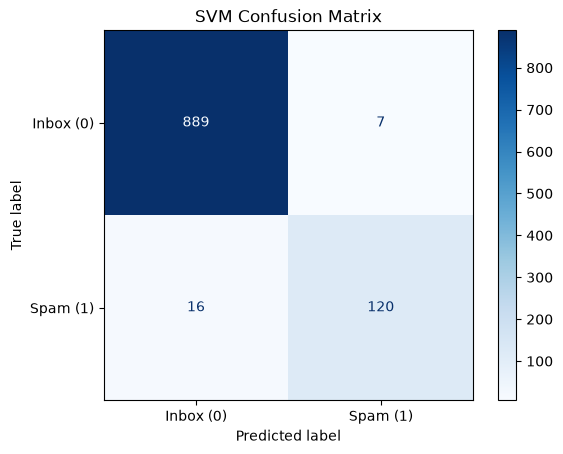

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Generate the raw confusion matrix numbers using our hidden test labels and SVM predictions
cm = confusion_matrix(y_test, svm_preds)

# 2. Configure the visual display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Inbox (0)', 'Spam (1)'])

# 3. Plot the matrix using a clean blue color scheme
disp.plot(cmap=plt.cm.Blues)
plt.title("SVM Confusion Matrix")
plt.show()

In [11]:
import joblib
import os

# 1. Ensure the models directory exists (just in case)
os.makedirs('../models', exist_ok=True)

# 2. Save the trained SVM model
joblib.dump(svm_model, '../models/spam_svm_model.joblib')

# 3. Save the TF-IDF Vectorizer
joblib.dump(vectorizer, '../models/tfidf_vectorizer.joblib')

print("Success! Model and Vectorizer saved to the /models folder.")

Success! Model and Vectorizer saved to the /models folder.
